# Loss Curve Test: `no_comms` size-25 architecture comparison at `init_scale=0.001`

This notebook is a focused test case for adapted ANN/RNN loss-curve plotting.

It compares three architectures:
- `task_routed`: `two_module_rnn_25_task_routed_no_comms_nb2_init0.001`
- `shared`: `two_module_rnn_25_no_comms_nb2_init0.001`
- `single_module`: `single_module_rnn_50_nb2_init0.001`

The loss-curve helper avoids the original Holton `[1::2]` slicing and instead optionally filters by saved `probes`.


In [1]:
from pathlib import Path
import os
import json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

project_root = Path.cwd().resolve()
if project_root.name != 'a1b2_modular':
    if (project_root / 'a1b2_modular').exists():
        project_root = project_root / 'a1b2_modular'
    else:
        for parent in [project_root, *project_root.parents]:
            if parent.name == 'a1b2_modular':
                project_root = parent
                break
os.chdir(project_root)

from a1b2.utils.run_config import build_run_id

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)

sim_root = project_root / 'data' / 'simulations'
config_path = project_root / 'a1b2' / 'models' / 'experiments.json'
settings = json.loads(config_path.read_text())

architecture_order = ['task_routed', 'shared', 'single_module']
architecture_palette = {
    'task_routed': '#4C72B0',
    'shared': '#55A868',
    'single_module': '#C44E52',
}
condition_order = ['same', 'near', 'far']
phase_order = ['A1', 'B', 'A2']

name_to_group = {
    'two_module_rnn_25_task_routed_no_comms_nb2_init0.01': 'task_routed',
    'two_module_rnn_25_no_comms_nb2_init0.01': 'shared',
    'single_module_rnn_50_nb2_init0.01': 'single_module',
}

rows = []
for name, arch_group in name_to_group.items():
    condition = next(c for c in settings['conditions'] if c['name'] == name)
    run_id = build_run_id(condition)
    folder = sim_root / run_id
    rows.append({
        'condition_name': name,
        'architecture_group': arch_group,
        'run_id': run_id,
        'folder_path': str(folder),
        'path_exists': folder.exists(),
        'n_npz': len(list(folder.glob('sim_*.npz'))) if folder.exists() else 0,
    })

grid_df = pd.DataFrame(rows)
display(grid_df)


/home/kat/workspace/Structure-Function-Analysis-of-Network-Topologies/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,condition_name,architecture_group,run_id,folder_path,path_exists,n_npz
0,two_module_rnn_25_task_routed_no_comms_nb2_ini...,task_routed,two_module_rnn_25_task_routed_no_comms_nb2_ini...,/home/kat/workspace/Structure-Function-Analysi...,True,305
1,two_module_rnn_25_no_comms_nb2_init0.01,shared,two_module_rnn_25_no_comms_nb2_init0.01_nb2_sh...,/home/kat/workspace/Structure-Function-Analysi...,True,305
2,single_module_rnn_50_nb2_init0.01,single_module,single_module_rnn_50_nb2_init0.01_nb2_shared_s...,/home/kat/workspace/Structure-Function-Analysi...,True,305


In [2]:
def load_raw_ann_folder(folder: Path, keys=None):
    keys = ['losses', 'accuracy', 'probes', 'test_stim'] if keys is None else list(keys)
    condition_data = {'same': [], 'near': [], 'far': []}
    if not folder.exists():
        return condition_data
    for npz_path in sorted(folder.glob('sim_*.npz')):
        file_name = npz_path.name
        condition = next((cond for cond in condition_data if cond in file_name), None)
        if condition is None:
            continue
        with np.load(npz_path, allow_pickle=True) as data:
            entry = {'participant': npz_path.stem.replace('sim_', '')}
            for key in keys:
                if key in data:
                    entry[key] = data[key]
        condition_data[condition].append(entry)
    return condition_data


def load_curve_df(
    grid: pd.DataFrame,
    value_key: str,
    probe_filter=None,
    test_stim_filter=None,
    max_phase_trial_index_exclusive=None,
):
    """Load per-trial series. If max_phase_trial_index_exclusive is set, keep only trial_idx < that value within each phase (chronological index in saved arrays)."""
    rows = []
    valid_grid = grid[grid['path_exists']].copy()
    for _, row in tqdm(valid_grid.iterrows(), total=len(valid_grid), desc=f'Loading {value_key} curves'):
        ann_data = load_raw_ann_folder(Path(row['folder_path']), keys=[value_key, 'probes', 'test_stim'])
        for condition, entries in ann_data.items():
            for entry in entries:
                if value_key not in entry or 'probes' not in entry or 'test_stim' not in entry:
                    continue
                values = np.asarray(entry[value_key])
                probes = np.asarray(entry['probes'])
                test_stim = np.asarray(entry['test_stim'])
                if values.ndim != 2 or probes.ndim != 2 or test_stim.ndim != 2:
                    continue
                n_phases, n_trials = values.shape
                for phase_idx in range(min(3, n_phases)):
                    phase_name = phase_order[phase_idx]
                    phase_values = values[phase_idx].astype(float)
                    phase_probes = probes[phase_idx].astype(float)
                    phase_test = test_stim[phase_idx].astype(float)
                    valid = np.isfinite(phase_values) & np.isfinite(phase_probes) & np.isfinite(phase_test)
                    if probe_filter is not None:
                        valid = valid & (phase_probes == probe_filter)
                    if test_stim_filter is not None:
                        valid = valid & (phase_test == test_stim_filter)
                    valid_idx = np.where(valid)[0]
                    if max_phase_trial_index_exclusive is not None:
                        valid_idx = valid_idx[valid_idx < max_phase_trial_index_exclusive]
                    for local_order, trial_idx in enumerate(valid_idx):
                        rows.append({
                            'architecture_group': row['architecture_group'],
                            'run_id': row['run_id'],
                            'participant': entry['participant'],
                            'condition': condition,
                            'phase': phase_name,
                            'trial_idx_within_phase': int(local_order),
                            'global_trial_idx': int(phase_idx * n_trials + trial_idx),
                            'value': float(phase_values[trial_idx]),
                            'probe': int(phase_probes[trial_idx]),
                            'test_stim': int(phase_test[trial_idx]),
                        })
    return pd.DataFrame(rows)


def summarize_curves(curve_df: pd.DataFrame, smooth_window=None, value_label='value'):
    if curve_df is None or curve_df.empty:
        return pd.DataFrame()
    summary = (
        curve_df.groupby(['architecture_group', 'condition', 'phase', 'global_trial_idx'], observed=True)
        .agg(mean_value=('value', 'mean'), sem_value=('value', 'sem'), n=('participant', 'nunique'))
        .reset_index()
        .sort_values(['architecture_group', 'condition', 'phase', 'global_trial_idx'])
    )
    summary = summary.rename(columns={'mean_value': f'mean_{value_label}', 'sem_value': f'sem_{value_label}'})
    if smooth_window is not None and smooth_window > 1:
        summary[f'mean_{value_label}'] = (
            summary.groupby(['architecture_group', 'condition', 'phase'], observed=True)[f'mean_{value_label}']
            .transform(lambda s: s.rolling(smooth_window, min_periods=1, center=True).mean())
        )
        summary[f'sem_{value_label}'] = (
            summary.groupby(['architecture_group', 'condition', 'phase'], observed=True)[f'sem_{value_label}']
            .transform(lambda s: s.fillna(0).rolling(smooth_window, min_periods=1, center=True).mean())
        )
    return summary


# Holton-style window: first 50 "repetitions" per task phase while training uses 100 (see paper: show early learning before plateau).
# Here one repetition ~= one epoch sweep; trial count per epoch = n_trials_phase // n_epochs.
PAPER_N_EPOCHS_TOTAL = 100
PAPER_FIRST_N_REPS = 50
_sample_rows = grid_df.loc[grid_df['path_exists'], 'folder_path']
max_phase_trial_idx_paper_first50 = None
if len(_sample_rows) > 0:
    _sample_folder = Path(_sample_rows.iloc[0])
    _sample_npz = next(_sample_folder.glob('sim_*.npz'), None)
    if _sample_npz is not None:
        with np.load(_sample_npz) as _d:
            _n_trials_phase = int(_d['losses'].shape[1])
        _n_epochs_cfg = PAPER_N_EPOCHS_TOTAL
        _settings_path = _sample_folder / 'settings.json'
        if _settings_path.exists():
            _settings_json = json.loads(_settings_path.read_text())
            _n_epochs_cfg = int(_settings_json.get('training_params', {}).get('n_epochs', PAPER_N_EPOCHS_TOTAL))
        _trials_per_rep = _n_trials_phase // _n_epochs_cfg
        max_phase_trial_idx_paper_first50 = PAPER_FIRST_N_REPS * _trials_per_rep
        print(
            'Paper-style first-50-reps window:',
            f'n_trials_per_phase={_n_trials_phase}, n_epochs={_n_epochs_cfg},',
            f'trials_per_rep≈{_trials_per_rep}, max_phase_trial_idx={max_phase_trial_idx_paper_first50}',
        )


loss_df_all = load_curve_df(grid_df, value_key='losses', probe_filter=None)
loss_df_summer = load_curve_df(grid_df, value_key='losses', probe_filter=0)
loss_df_winter = load_curve_df(grid_df, value_key='losses', probe_filter=1)
loss_df_winter_train_only = load_curve_df(grid_df, value_key='losses', probe_filter=1, test_stim_filter=0)
loss_df_winter_test_only = load_curve_df(grid_df, value_key='losses', probe_filter=1, test_stim_filter=1)

loss_summary_all = summarize_curves(loss_df_all, value_label='loss')
loss_summary_summer = summarize_curves(loss_df_summer, value_label='loss')
loss_summary_winter = summarize_curves(loss_df_winter, value_label='loss')
loss_summary_winter_train_only = summarize_curves(loss_df_winter_train_only, value_label='loss')
loss_summary_winter_test_only = summarize_curves(loss_df_winter_test_only, value_label='loss')
loss_summary_winter_smoothed = summarize_curves(loss_df_winter, smooth_window=25, value_label='loss')
loss_summary_all_smoothed = summarize_curves(loss_df_all, smooth_window=25, value_label='loss')

accuracy_df_all = load_curve_df(grid_df, value_key='accuracy', probe_filter=None)
accuracy_df_summer = load_curve_df(grid_df, value_key='accuracy', probe_filter=0)
accuracy_df_winter = load_curve_df(grid_df, value_key='accuracy', probe_filter=1)
accuracy_df_winter_train_only = load_curve_df(grid_df, value_key='accuracy', probe_filter=1, test_stim_filter=0)

accuracy_summary_all = summarize_curves(accuracy_df_all, value_label='accuracy')
accuracy_summary_summer = summarize_curves(accuracy_df_summer, value_label='accuracy')
accuracy_summary_winter = summarize_curves(accuracy_df_winter, value_label='accuracy')
accuracy_summary_winter_train_only = summarize_curves(accuracy_df_winter_train_only, value_label='accuracy')
accuracy_summary_winter_smoothed = summarize_curves(accuracy_df_winter, smooth_window=25, value_label='accuracy')
accuracy_summary_all_smoothed = summarize_curves(accuracy_df_all, smooth_window=25, value_label='accuracy')

if max_phase_trial_idx_paper_first50 is not None:
    loss_df_all_first50 = load_curve_df(
        grid_df, value_key='losses', probe_filter=None, max_phase_trial_index_exclusive=max_phase_trial_idx_paper_first50,
    )
    loss_df_summer_first50 = load_curve_df(
        grid_df, value_key='losses', probe_filter=0, max_phase_trial_index_exclusive=max_phase_trial_idx_paper_first50,
    )
    loss_summary_all_first50 = summarize_curves(loss_df_all_first50, value_label='loss')
    loss_summary_summer_first50 = summarize_curves(loss_df_summer_first50, value_label='loss')

    accuracy_df_all_first50 = load_curve_df(
        grid_df, value_key='accuracy', probe_filter=None, max_phase_trial_index_exclusive=max_phase_trial_idx_paper_first50,
    )
    accuracy_df_summer_first50 = load_curve_df(
        grid_df, value_key='accuracy', probe_filter=0, max_phase_trial_index_exclusive=max_phase_trial_idx_paper_first50,
    )
    accuracy_summary_all_first50 = summarize_curves(accuracy_df_all_first50, value_label='accuracy')
    accuracy_summary_summer_first50 = summarize_curves(accuracy_df_summer_first50, value_label='accuracy')
else:
    print('Paper first-50 window unavailable (no sample .npz); first-50 curves will be empty.')
    loss_df_all_first50 = pd.DataFrame()
    loss_df_summer_first50 = pd.DataFrame()
    loss_summary_all_first50 = pd.DataFrame()
    loss_summary_summer_first50 = pd.DataFrame()
    accuracy_df_all_first50 = pd.DataFrame()
    accuracy_df_summer_first50 = pd.DataFrame()
    accuracy_summary_all_first50 = pd.DataFrame()
    accuracy_summary_summer_first50 = pd.DataFrame()


print('loss_df_all', loss_df_all.shape)
print('loss_df_summer', loss_df_summer.shape)
print('loss_df_winter', loss_df_winter.shape)
print('loss_df_winter_train_only', loss_df_winter_train_only.shape)
print('accuracy_df_all', accuracy_df_all.shape)
print('accuracy_df_summer', accuracy_df_summer.shape)
print('accuracy_df_winter', accuracy_df_winter.shape)
print('accuracy_df_winter_train_only', accuracy_df_winter_train_only.shape)
print('loss_df_all_first50', loss_df_all_first50.shape)
print('loss_df_summer_first50', loss_df_summer_first50.shape)
print('accuracy_df_all_first50', accuracy_df_all_first50.shape)
print('accuracy_df_summer_first50', accuracy_df_summer_first50.shape)
display(loss_summary_all.head())
display(accuracy_summary_all.head())


Paper-style first-50-reps window: n_trials_per_phase=12000, n_epochs=100, trials_per_rep≈120, max_phase_trial_idx=6000


Loading losses curves:   0%|          | 0/3 [00:00<?, ?it/s]

Loading accuracy curves: 100%|██████████| 3/3 [00:38<00:00, 12.91s/it]


loss_df_all (32940000, 10)
loss_df_summer (16470000, 10)
loss_df_winter (16470000, 10)
loss_df_winter_train_only (14640000, 10)
accuracy_df_all (32940000, 10)
accuracy_df_summer (16470000, 10)
accuracy_df_winter (16470000, 10)
accuracy_df_winter_train_only (14640000, 10)
loss_df_all_first50 (16470000, 10)
loss_df_summer_first50 (8235000, 10)
accuracy_df_all_first50 (16470000, 10)
accuracy_df_summer_first50 (8235000, 10)


,architecture_group,condition,phase,global_trial_idx,mean_loss,sem_loss,n
0,shared,far,A1,0,0.500075,0.000131,101
1,shared,far,A1,1,0.499995,0.000119,101
2,shared,far,A1,2,0.505727,0.001267,101
3,shared,far,A1,3,0.504374,0.001149,101
4,shared,far,A1,4,0.506119,0.001641,101


,architecture_group,condition,phase,global_trial_idx,mean_accuracy,sem_accuracy,n
0,shared,far,A1,0,0.492477,0.029429,101
1,shared,far,A1,1,0.512872,0.028744,101
2,shared,far,A1,2,0.381419,0.025345,101
3,shared,far,A1,3,0.393907,0.024671,101
4,shared,far,A1,4,0.456089,0.032772,101


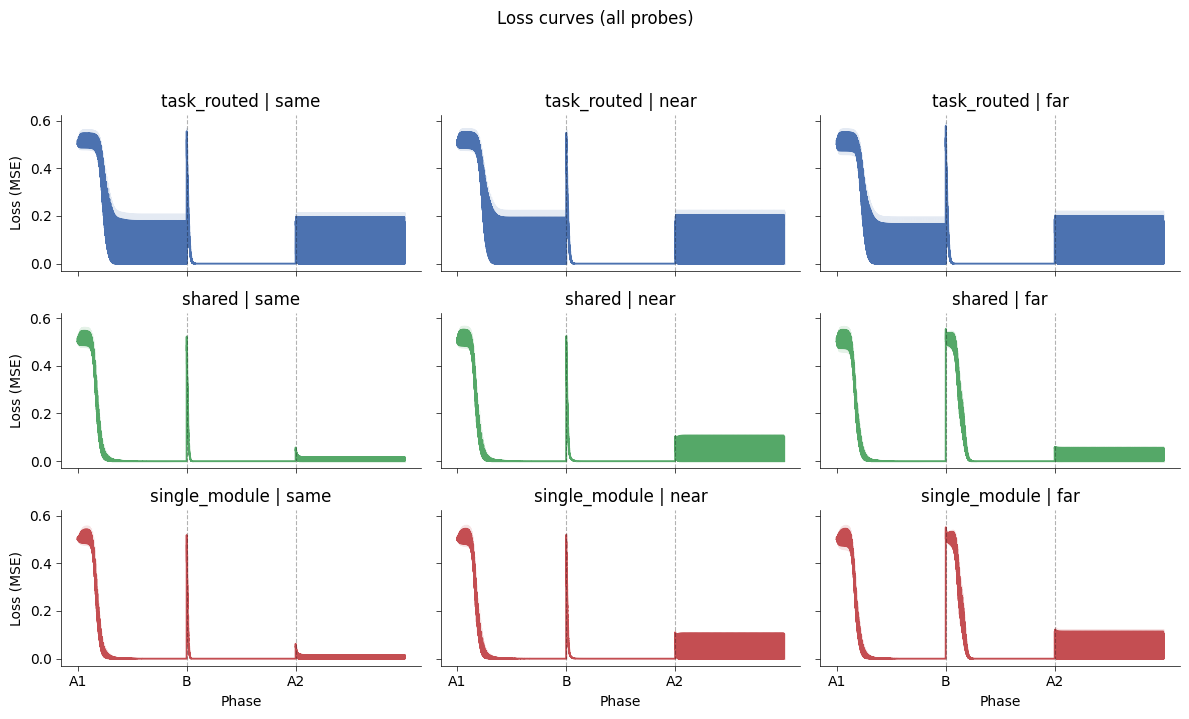

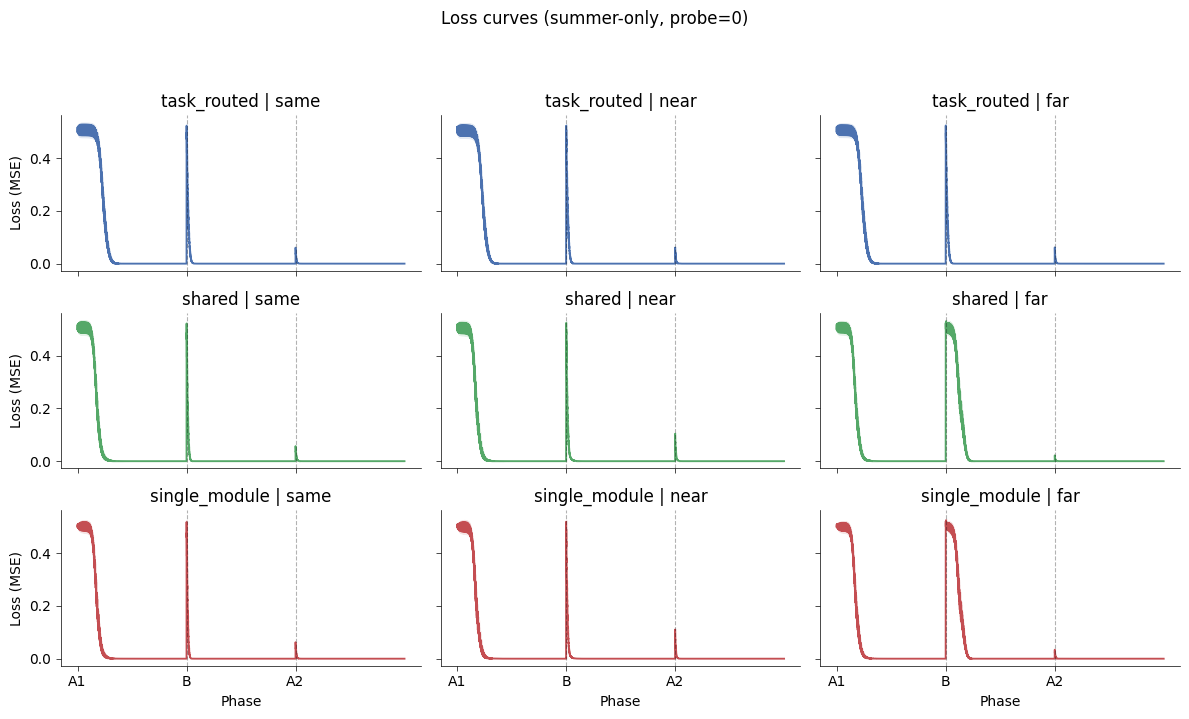

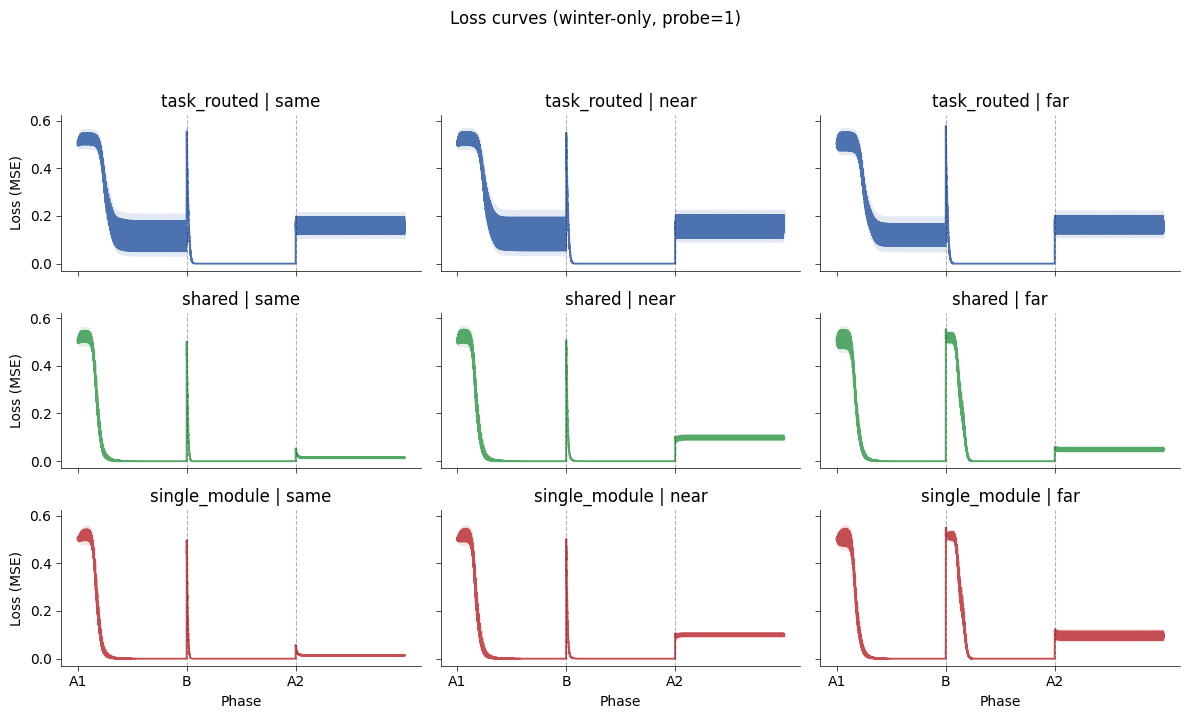

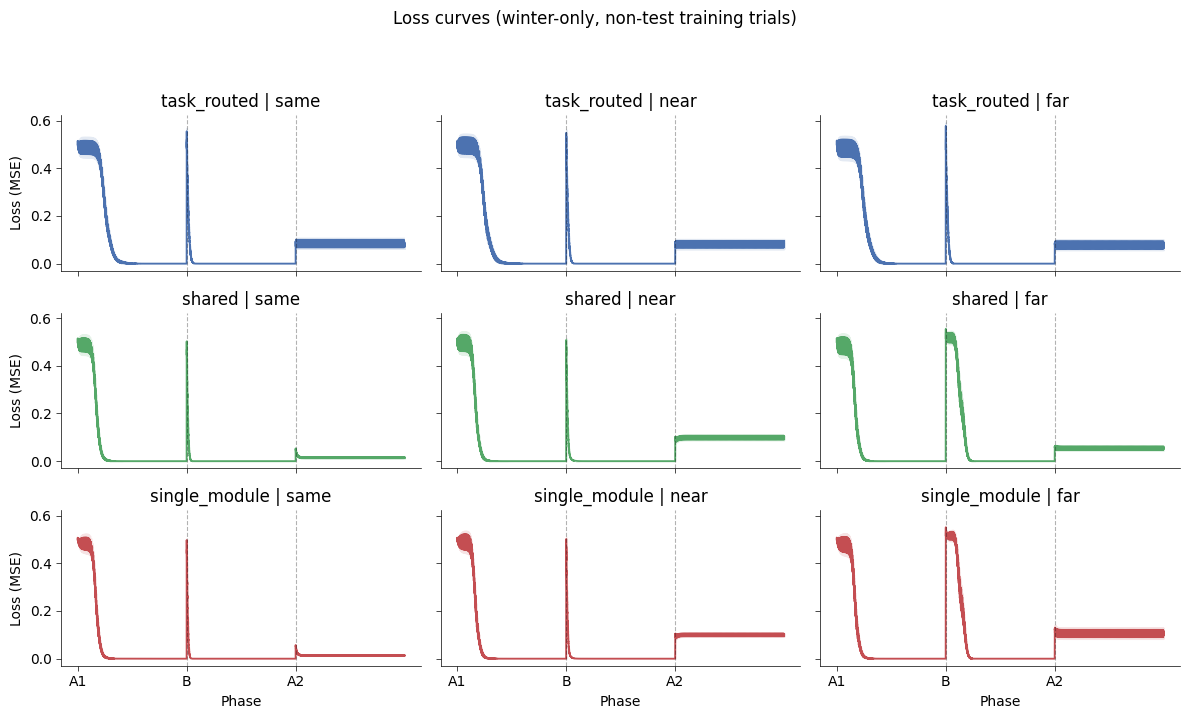

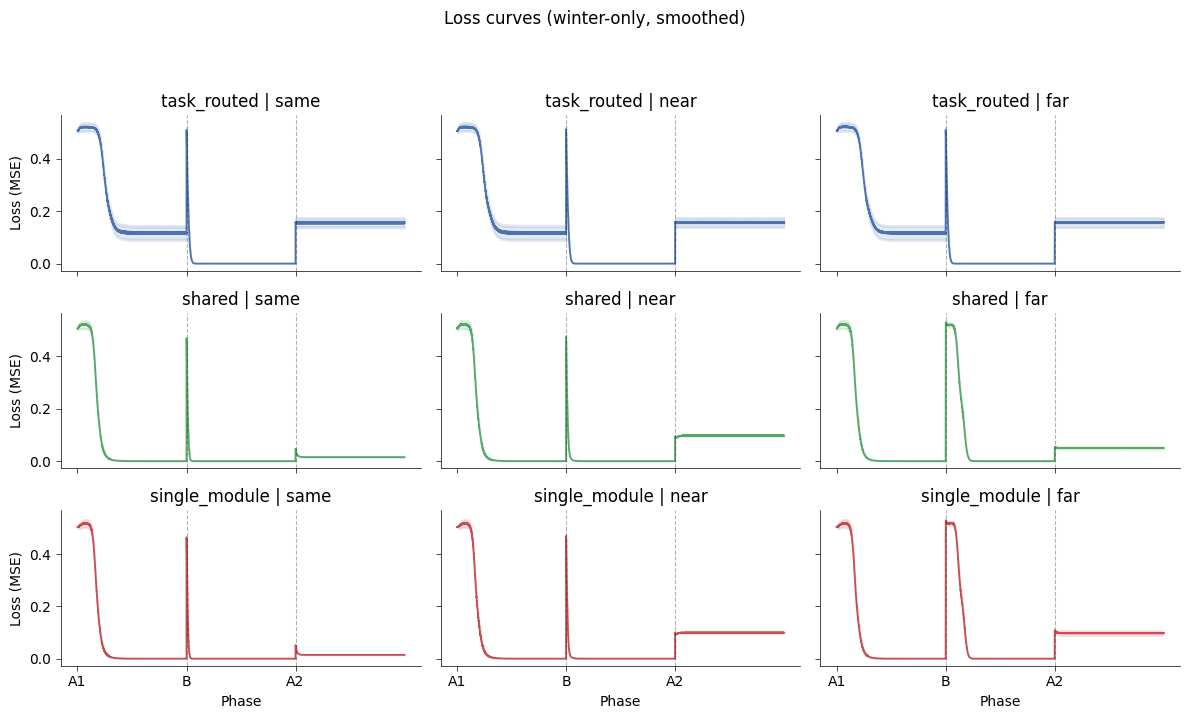

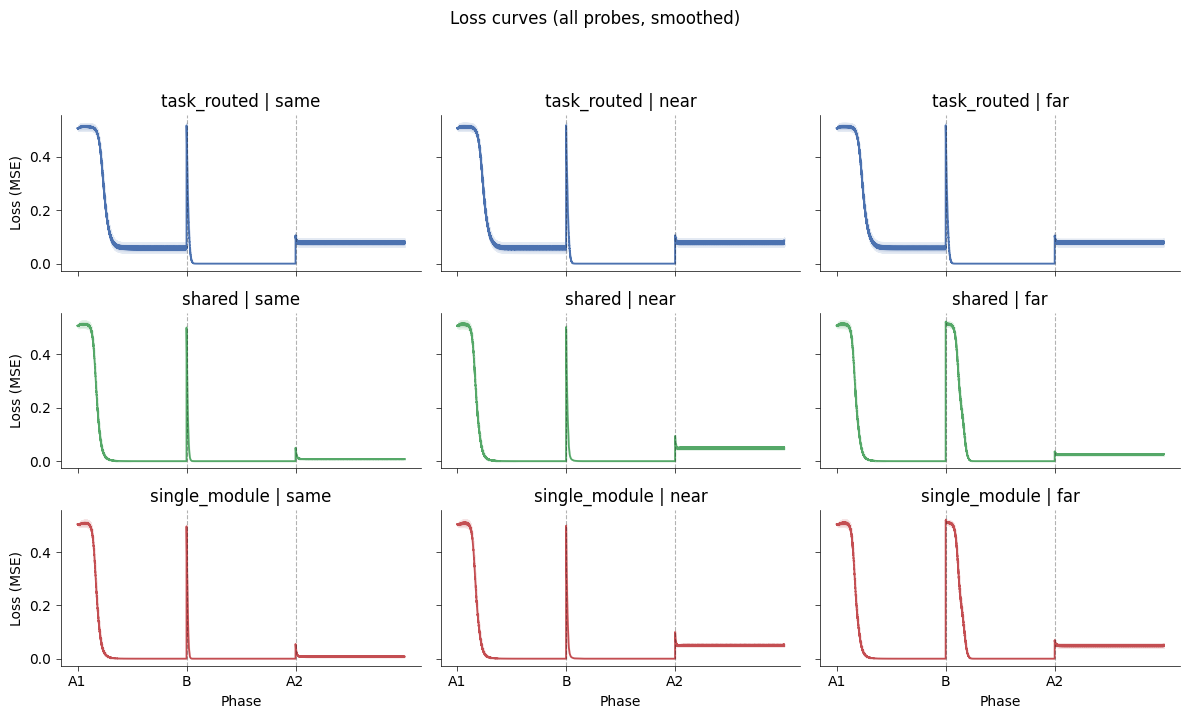

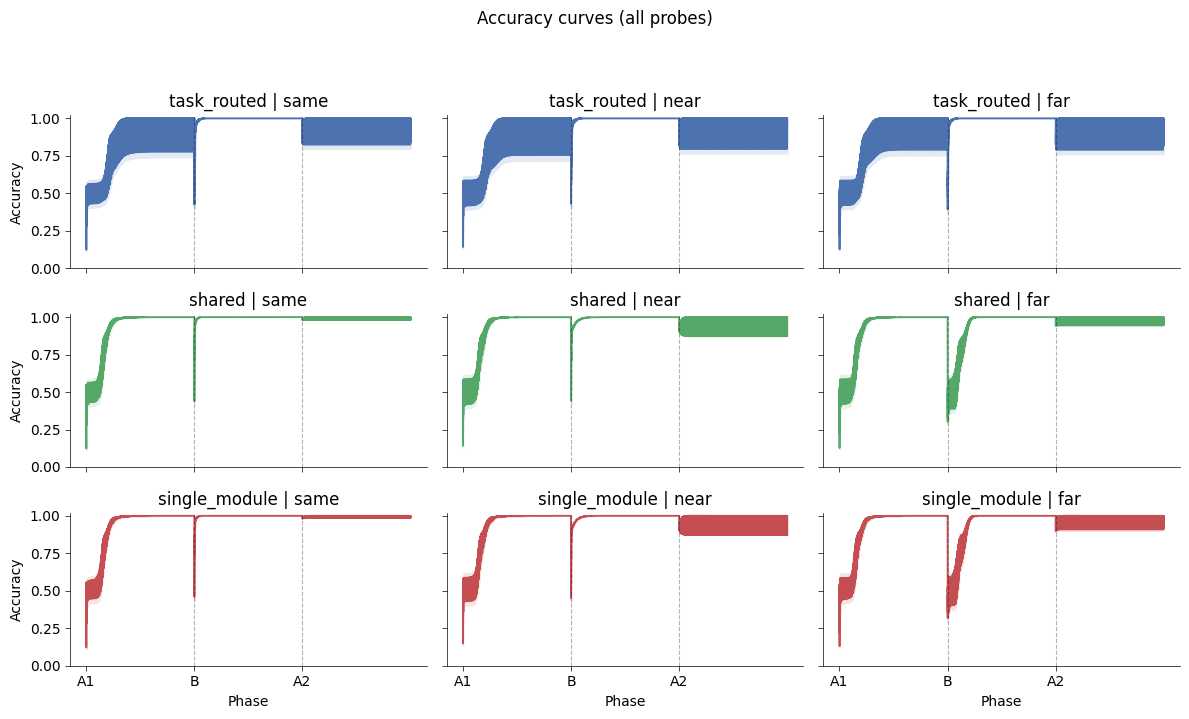

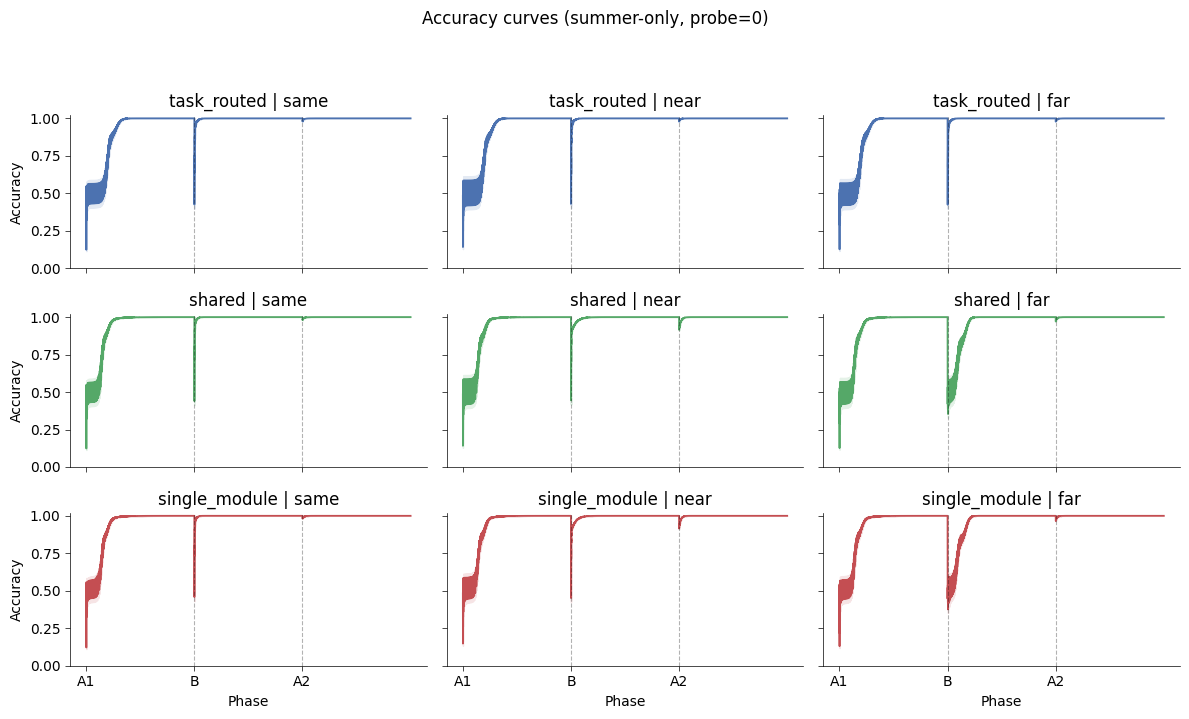

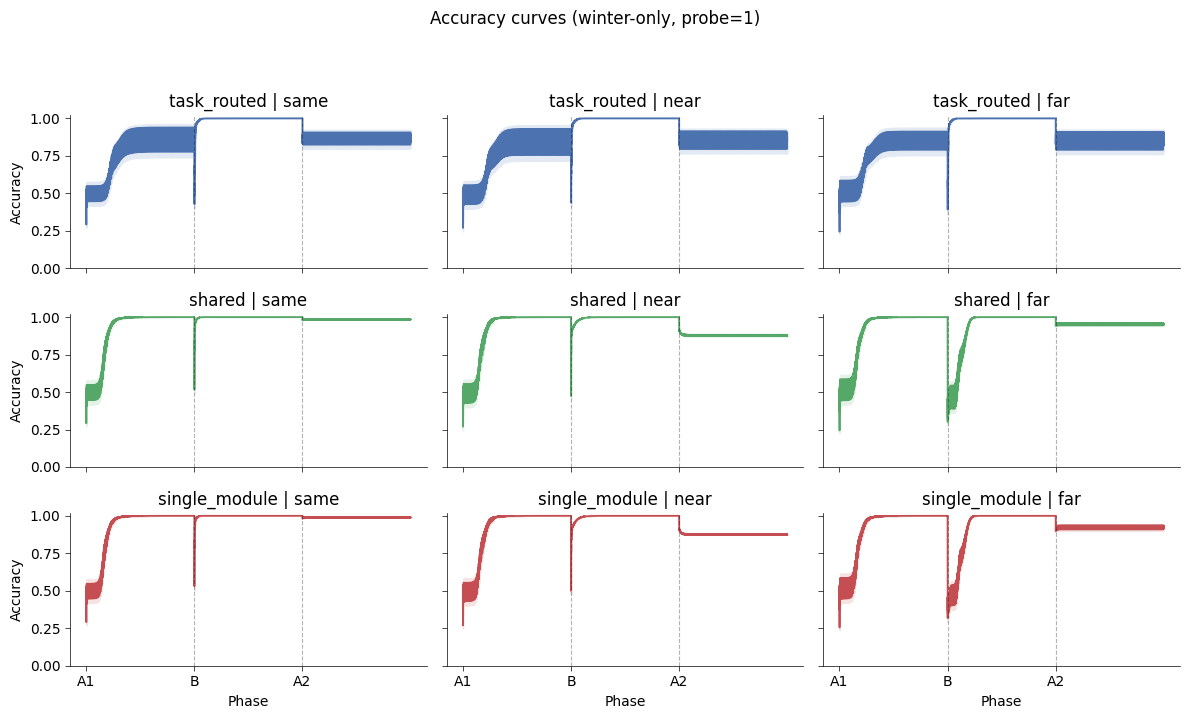

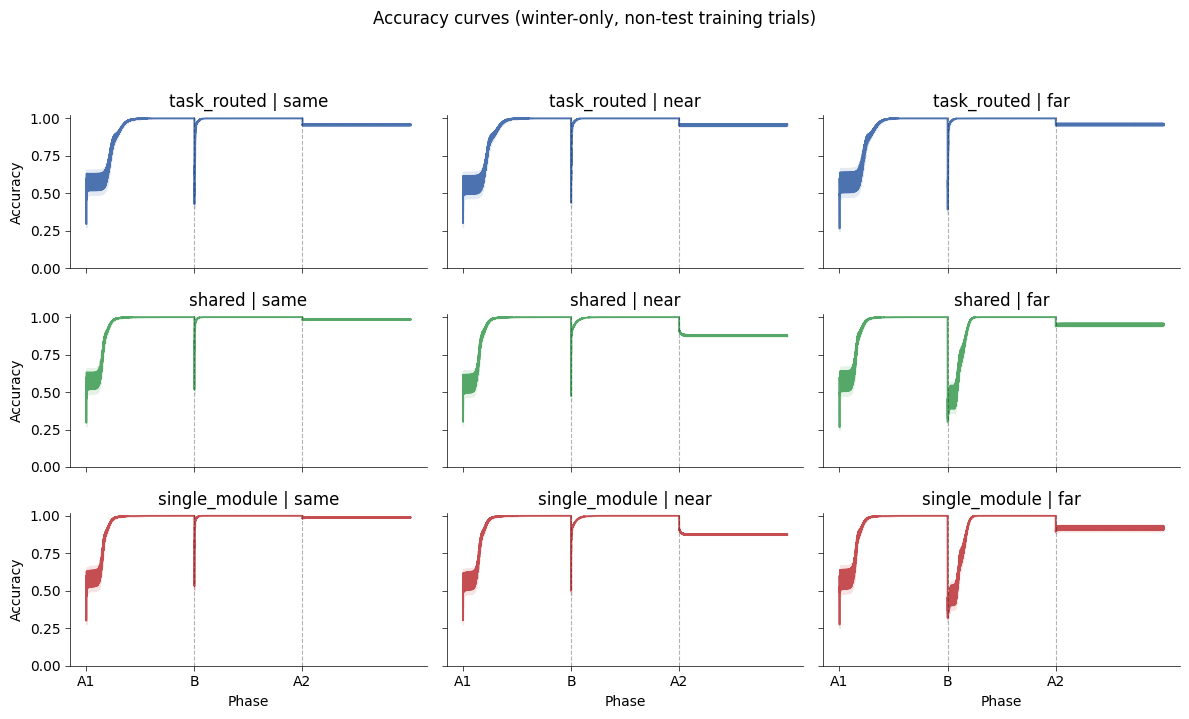

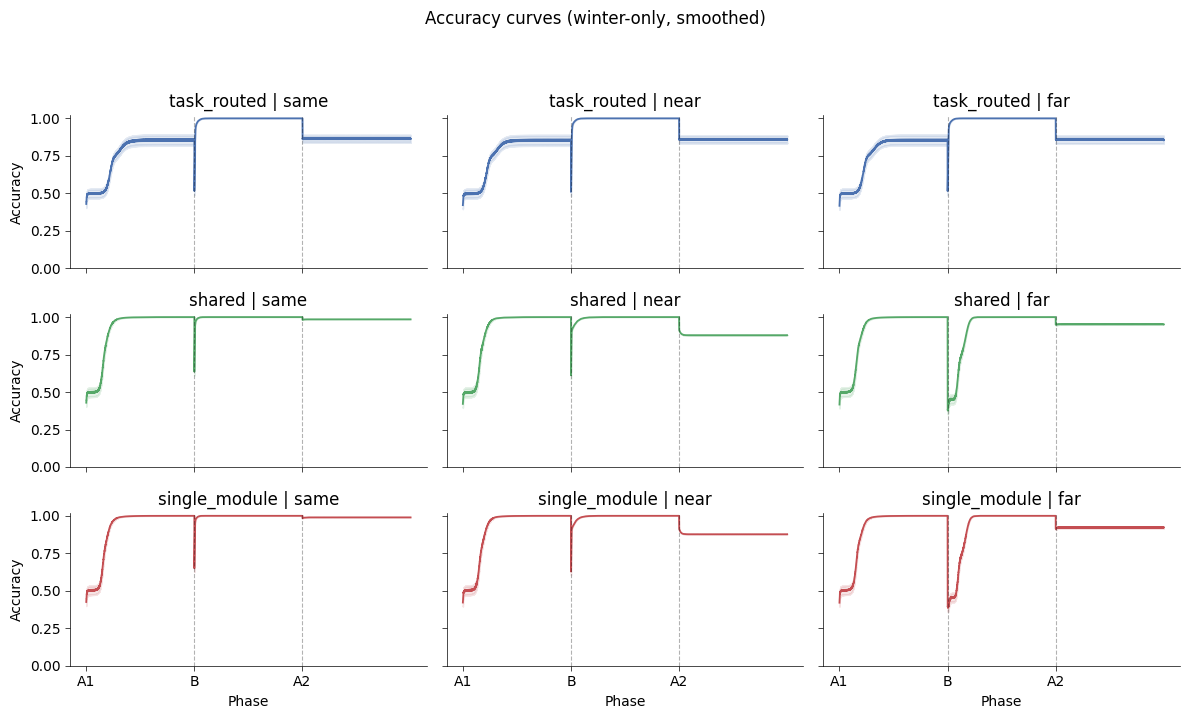

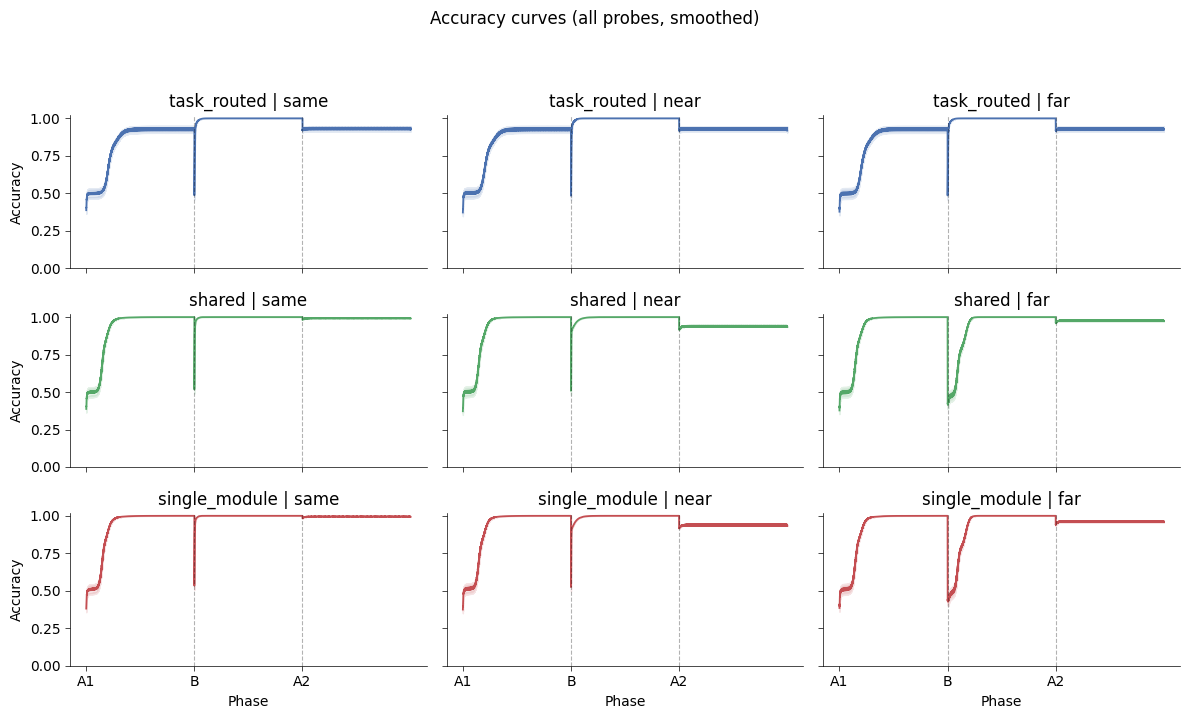

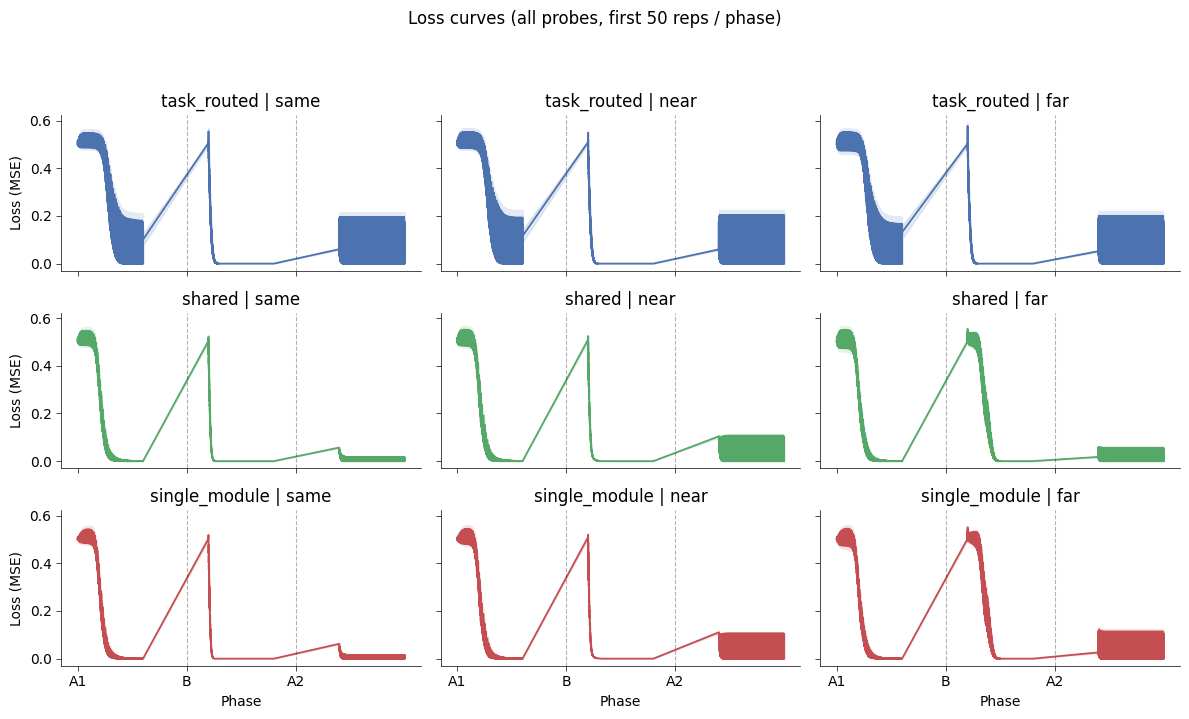

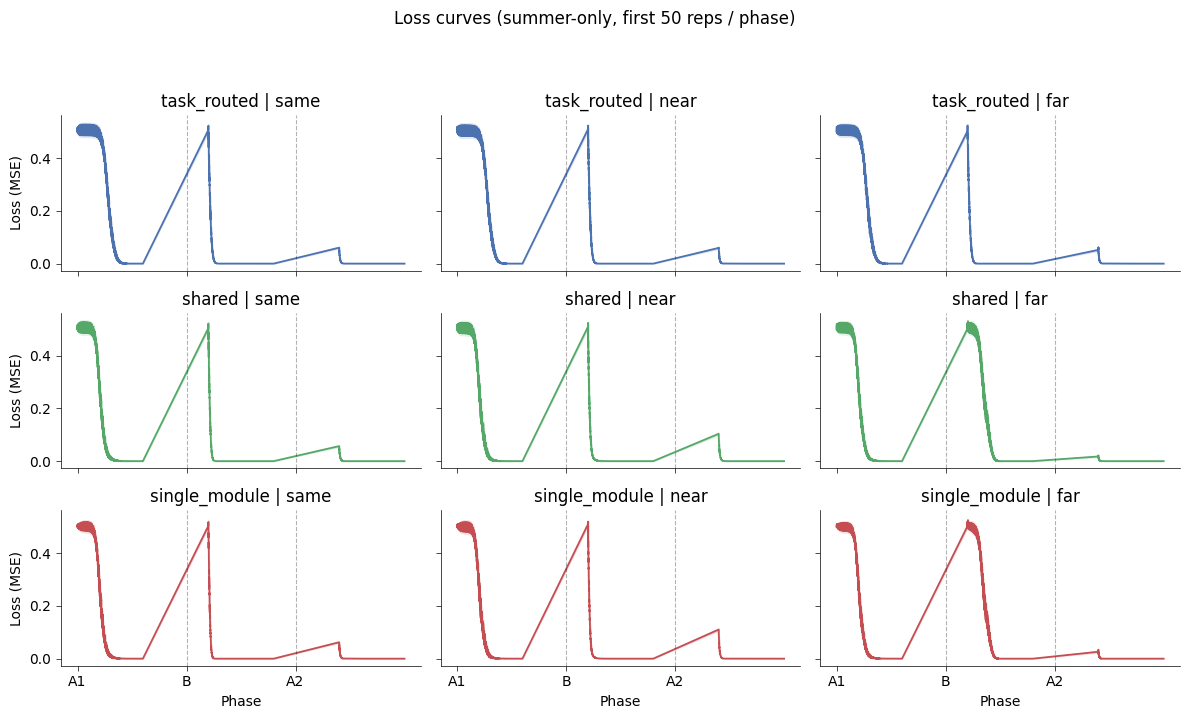

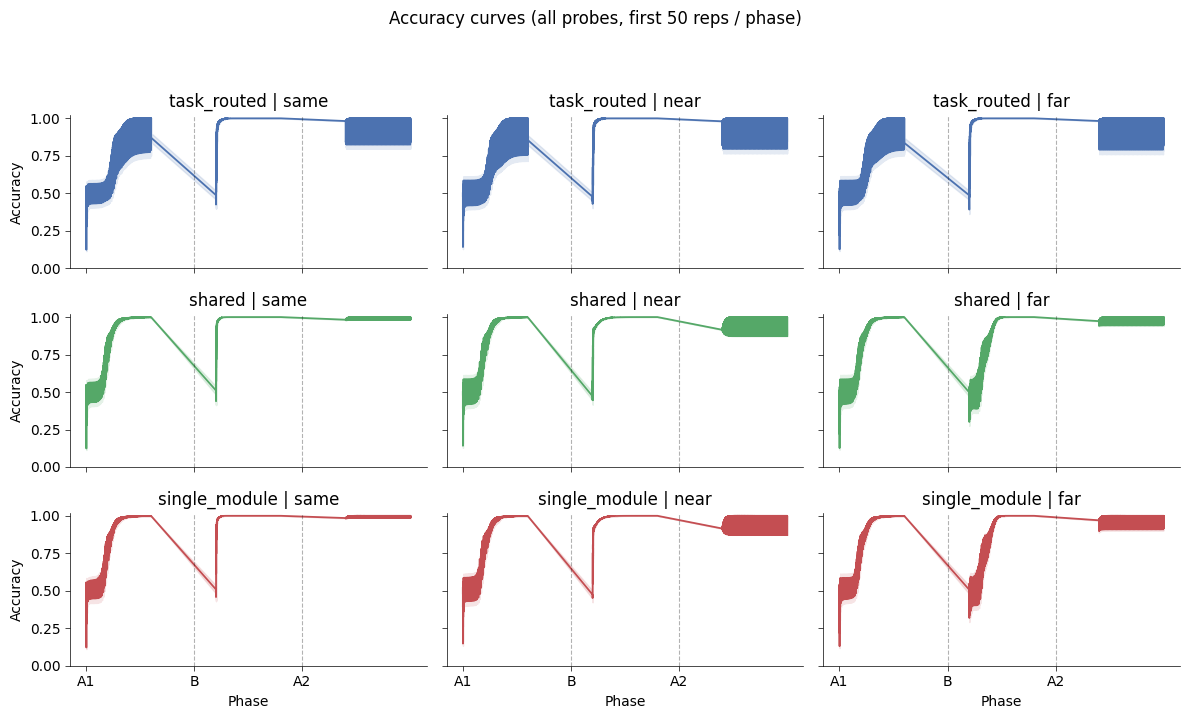

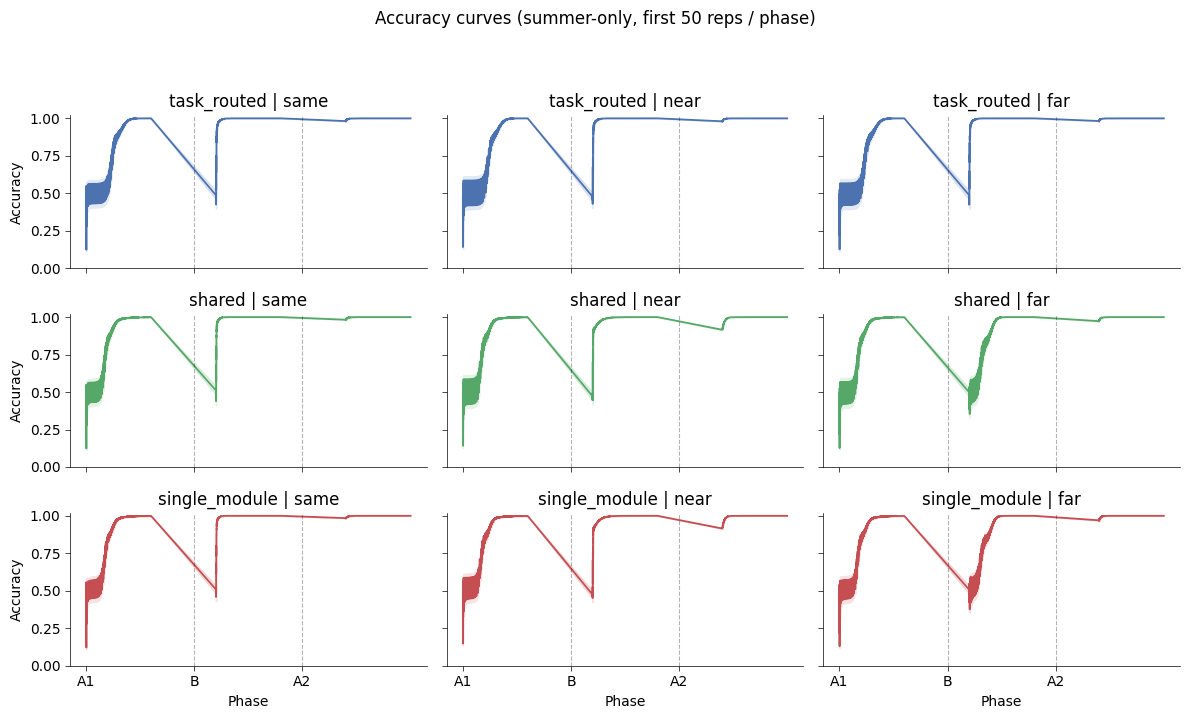

In [3]:
def _style_axes(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(0.5)
    ax.spines['bottom'].set_linewidth(0.5)
    ax.tick_params(colors='black', width=0.5)
    ax.grid(False)


def plot_curves_multi_panel(summary_df: pd.DataFrame, title: str, *, mean_col: str, sem_col: str, y_label: str, y_limits=None):
    if summary_df is None or summary_df.empty:
        print(f'No rows for {title}.')
        return

    fig, axes = plt.subplots(len(architecture_order), len(condition_order), figsize=(12, 7), sharex=True, sharey=True)
    if len(architecture_order) == 1 and len(condition_order) == 1:
        axes = np.array([[axes]])
    elif len(architecture_order) == 1:
        axes = np.array([axes])
    elif len(condition_order) == 1:
        axes = np.array([[ax] for ax in axes])

    for row_idx, arch in enumerate(architecture_order):
        for col_idx, condition in enumerate(condition_order):
            ax = axes[row_idx, col_idx]
            sub = summary_df[
                (summary_df['condition'] == condition)
                & (summary_df['architecture_group'] == arch)
            ].copy()
            if sub.empty:
                ax.set_title(f'{arch} | {condition}')
                _style_axes(ax)
                continue

            sub = sub.sort_values('global_trial_idx')
            x = sub['global_trial_idx'].to_numpy()
            y = sub[mean_col].to_numpy()
            sem = sub[sem_col].fillna(0).to_numpy()

            ax.plot(x, y, color=architecture_palette[arch], linewidth=1.3)
            ax.fill_between(x, y - sem, y + sem, color=architecture_palette[arch], alpha=0.15)

            # Phase boundaries from data (first trial of B / A2). max_idx/3 fails for truncated
            # windows (e.g. first-50-reps per phase) where phases have unequal x-span.
            b_start = sub.loc[sub['phase'] == 'B', 'global_trial_idx'].min()
            a2_start = sub.loc[sub['phase'] == 'A2', 'global_trial_idx'].min()
            if pd.notna(b_start) and pd.notna(a2_start):
                ax.axvline(float(b_start), color='k', linestyle='--', alpha=0.3, linewidth=0.8)
                ax.axvline(float(a2_start), color='k', linestyle='--', alpha=0.3, linewidth=0.8)
                xticks = [0.0, float(b_start), float(a2_start)]
                ax.set_xticks(xticks)
                ax.set_xticklabels(['A1', 'B', 'A2'])

            if y_limits is not None:
                ax.set_ylim(*y_limits)
            ax.set_title(f'{arch} | {condition}')
            _style_axes(ax)

    for ax in axes[-1, :]:
        ax.set_xlabel('Phase')
    for ax in axes[:, 0]:
        ax.set_ylabel(y_label)

    fig.suptitle(title, y=1.02)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()


plot_curves_multi_panel(loss_summary_all, 'Loss curves (all probes)', mean_col='mean_loss', sem_col='sem_loss', y_label='Loss (MSE)')
plot_curves_multi_panel(loss_summary_summer, 'Loss curves (summer-only, probe=0)', mean_col='mean_loss', sem_col='sem_loss', y_label='Loss (MSE)')
plot_curves_multi_panel(loss_summary_winter, 'Loss curves (winter-only, probe=1)', mean_col='mean_loss', sem_col='sem_loss', y_label='Loss (MSE)')

# Additional candidate variants for matching the original ANN plot more closely
plot_curves_multi_panel(loss_summary_winter_train_only, 'Loss curves (winter-only, non-test training trials)', mean_col='mean_loss', sem_col='sem_loss', y_label='Loss (MSE)')
plot_curves_multi_panel(loss_summary_winter_smoothed, 'Loss curves (winter-only, smoothed)', mean_col='mean_loss', sem_col='sem_loss', y_label='Loss (MSE)')
plot_curves_multi_panel(loss_summary_all_smoothed, 'Loss curves (all probes, smoothed)', mean_col='mean_loss', sem_col='sem_loss', y_label='Loss (MSE)')

plot_curves_multi_panel(accuracy_summary_all, 'Accuracy curves (all probes)', mean_col='mean_accuracy', sem_col='sem_accuracy', y_label='Accuracy', y_limits=(0, 1.02))
plot_curves_multi_panel(accuracy_summary_summer, 'Accuracy curves (summer-only, probe=0)', mean_col='mean_accuracy', sem_col='sem_accuracy', y_label='Accuracy', y_limits=(0, 1.02))
plot_curves_multi_panel(accuracy_summary_winter, 'Accuracy curves (winter-only, probe=1)', mean_col='mean_accuracy', sem_col='sem_accuracy', y_label='Accuracy', y_limits=(0, 1.02))
plot_curves_multi_panel(accuracy_summary_winter_train_only, 'Accuracy curves (winter-only, non-test training trials)', mean_col='mean_accuracy', sem_col='sem_accuracy', y_label='Accuracy', y_limits=(0, 1.02))
plot_curves_multi_panel(accuracy_summary_winter_smoothed, 'Accuracy curves (winter-only, smoothed)', mean_col='mean_accuracy', sem_col='sem_accuracy', y_label='Accuracy', y_limits=(0, 1.02))
plot_curves_multi_panel(accuracy_summary_all_smoothed, 'Accuracy curves (all probes, smoothed)', mean_col='mean_accuracy', sem_col='sem_accuracy', y_label='Accuracy', y_limits=(0, 1.02))
# Holton-style: early learning window (first 50 reps / phase)
plot_curves_multi_panel(loss_summary_all_first50, 'Loss curves (all probes, first 50 reps / phase)', mean_col='mean_loss', sem_col='sem_loss', y_label='Loss (MSE)')
plot_curves_multi_panel(loss_summary_summer_first50, 'Loss curves (summer-only, first 50 reps / phase)', mean_col='mean_loss', sem_col='sem_loss', y_label='Loss (MSE)')
plot_curves_multi_panel(accuracy_summary_all_first50, 'Accuracy curves (all probes, first 50 reps / phase)', mean_col='mean_accuracy', sem_col='sem_accuracy', y_label='Accuracy', y_limits=(0, 1.02))
plot_curves_multi_panel(accuracy_summary_summer_first50, 'Accuracy curves (summer-only, first 50 reps / phase)', mean_col='mean_accuracy', sem_col='sem_accuracy', y_label='Accuracy', y_limits=(0, 1.02))


## Notes

- This test notebook is intentionally narrow: one init scale and three architecture groups.
- It compares three curve variants:
  - all losses
  - summer-only (`probe=0`)
  - winter-only (`probe=1`)
- The helper avoids the original Holton `[1::2]` slicing and instead uses saved `probes`.
